In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import opt_einsum as oe
import scipy.sparse as sp
import time

from quant_rotor.core.dense.t_amplitudes_guess import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state

from quant_rotor.models.dense.support_ham import write_matrix_elements, m_to_p, basis_m_to_p_matrix_conversion
from quant_rotor.models.dense.density_matrix import density_matrix_1, density_matrix_trans

from quant_rotor.core.dense.hamiltonian import hamiltonian_dense
from quant_rotor.core.dense.hamiltonian_big import hamiltonian_general_dense, hamiltonian_big_dense
from quant_rotor.core.sparse.hamiltonian_big import hamiltonian_general_sparse, hamiltonian_big_sparse
from quant_rotor.core.sparse.hamiltonian import hamiltonian_sparse

from quant_rotor.core.dense.t_amplitudes_periodic_fast import t_periodic as t_periodic_fast_d
from quant_rotor.core.sparse.t_amplitudes_periodic_fast import t_periodic as t_periodic_fast_s
from quant_rotor.core.dense.t_amplitudes_periodic import t_periodic

from quant_rotor.core.dense.de_solve_one_thermal import integration_scheme
from quant_rotor.core.dense.de_solve_one_thermal_dense import integration_scheme as integration_scheme_fast

np.set_printoptions(suppress = True, linewidth = 1500, threshold = np.inf, precision = 12)

# Graph 1

In [ ]:
site = 3
state = 9
state_NO = 5
final = 100

g = 0.2

In [15]:
def sites_CCC_func(site):

    _, energy, _, _ = integration_scheme(site, 11, g, t_init=0, t_final=100, nof_points=100000)

    return energy[-1].real

In [16]:
def sites_NO_func(site):

    H_NO, _, _ = hamiltonian_general_sparse(state, state_NO, site, g)
    print("Ham_Done")
    eig_val_NO, _ = sp.linalg.eigsh(H_NO, k=5, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val_NO)

In [17]:
def sites_ED_func(site):

    H, _, _ = hamiltonian_sparse(state, site, g)

    eig_val, _ = sp.linalg.eigsh(H, k=1, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val)

In [ ]:
n_CCC = 30
n_ED = 8
n_NO = 11

E_ED = np.zeros((n_ED))
E_NO = np.zeros((n_NO))
E_CCC = np.zeros((n_CCC))

sites_CCC = np.zeros((n_CCC))
sites_ED = np.zeros((n_ED))
sites_NO = np.zeros((n_NO))

In [8]:
for i in range(3, n_ED):

    E_ED[i - 3] = sites_ED_func(i)

    sites_ED[i-3] = i
    print(E_ED[i-3], sites_ED[i-3])

Finished site 0
Finished site 1
Finished site 2
-0.08587043888364759 3.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.1051692655128193 4.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
-0.12772411036754058 5.0
Finished site 0
Finished site 1


/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_89375/961205076.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  E_ED[i - 3] = sites_ED_func(i)


Finished site 2
Finished site 3
Finished site 4
Finished site 5
-0.15218930200930866 6.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 5
Finished site 6
-0.17715633332420402 7.0


In [ ]:
for i in range(3, n_CCC):

    E_CCC[i - 3] = sites_CCC_func(i)

    sites_CCC[i-3] = i
    print(E_CCC[i-3], sites_CCC[i-3])

-0.08793411470868667 3.0
-0.10783443349972918 4.0
-0.1306681226495107 5.0
-0.1555131175183597 6.0
-0.18091707548387057 7.0
-0.20656931131393955 8.0
-0.2323130022248852 9.0
-0.2580946139779799 10.0
-0.2838914328270877 11.0
-0.3096945528694664 12.0
-0.3355002785395787 13.0
-0.36130709406556544 14.0
-0.38711436689079326 15.0
-0.41292183265733934 16.0
-0.4387293800964248 17.0
-0.464536962226413 18.0
-0.4903445591308087 19.0
-0.5161521623428728 20.0
-0.5419597682535056 21.0
-0.5677673753208173 22.0
-0.5935749828847356 23.0
-0.6193825906621809 24.0
-0.645190198531564 25.0
-0.6709978064405776 26.0


In [ ]:
plt.plot(x_bigger_basis, np.log10(y_bigger_basis), label=f"#Basis size before truncation = {31}, NO = {state_NO}")
plt.plot((x), np.log10(y), label=f"#Basis size before truncation = {21}, NO = {state_NO}")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B /> 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()
plt.show()

# Graph #2

In [54]:
def calculate_xy_no_field(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = site

    g = 1
    D_val = 1 * 10**(-num)

    if site_i == 2:
        periodic = False
    else:
        periodic = True

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    _, energy, _, _, _ = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    E_CC = np.abs(energy[-1].real)
    E_ED = np.abs(np.min(eig_val_loc).real)

    per_diff = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200

    print(E_CC.real, E_ED.real)

    return (np.log10(D_val)).real, per_diff

In [55]:
site = 2
state = 21
state_NO = 5
final = 400

In [56]:
n = 6
x = np.zeros((n))
y = np.zeros((n))

for i in range(n):
    x[i], y[i] = calculate_xy_no_field(site, state, state_NO, final, i)
    print(x[i], y[i])

ED done.
0.3631883029431415 0.5129981196637204
0.0 34.19587723691478
ED done.
1.4184233538348412 1.41539738152528
-1.0 0.21356130765812908
ED done.
1.8101878039844657 1.809345151573959
-2.0 0.046561389044003546
ED done.
1.934365838630262 1.9343186584246572
-3.0 0.0024390826204983866
ED done.
1.958613621704378 1.9586130715959311
-4.0 2.8086628110443985e-05
ED done.
1.961371405493912 1.9613714017232793
-5.0 1.9224470633296127e-07


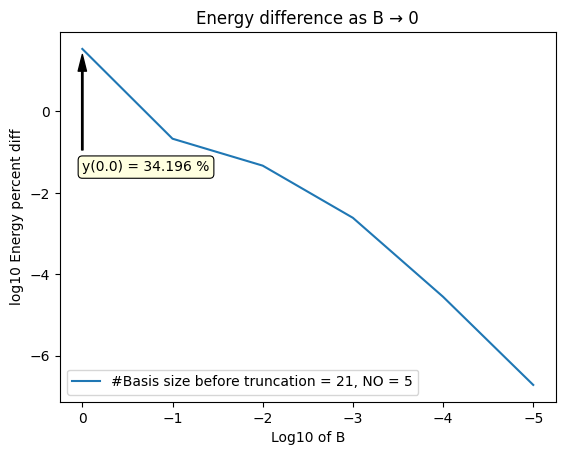

In [59]:
plt.plot((x), np.log10(y), label=f"#Basis size before truncation = {21}, NO = {state_NO}")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B → 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()

x0 = x[0]
y0 = np.log10(y)[0]

plt.annotate(
    f"y({x[0]}) = {y[0]:.3f} %",
    xy=(x0, y0),                  # point to (x=0, y=y0)
    xytext=(0, y0 -3),      # position of text box
    textcoords='data',
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="black", lw=0.8),
    fontsize=10
)
plt.show()

In [50]:
y_bigger_basis

array([34.195877236915,  0.213561307658,  0.046561389044,  0.00243908262 ,  0.000028086628,  0.000000192245,  0.00000000775 ,  0.000000001046,  0.000000000107,  0.000000000011,  0.000000000001,  0.            ,  0.            ,  0.            ,  0.            ])

# Graph 3

In [2]:
def calculate_g(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = 4

    g = 1
    D_val = num

    periodic = False

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    periodic = True

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)
    D_del = density_matrix_1(state, site, psi_1, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    eig_val_D_del, matrix_p_to_NO_full_del = np.linalg.eigh(D_del)
    index_d_del = np.argsort(-eig_val_D_del)
    matrix_p_to_NO_del = matrix_p_to_NO_full_del[:, index_d_del[:state_NO]]

    K_NO_del = matrix_p_to_NO_del.T.conj() @ K @ matrix_p_to_NO_del
    matrix_p_to_NO_V_del = np.kron(matrix_p_to_NO_del, matrix_p_to_NO_del)
    V_NO_del = matrix_p_to_NO_V_del.conj().T @ V @ matrix_p_to_NO_V_del

    H_NO_del, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO_del, V_import=V_NO_del, Import_K_V=True, periodic=periodic)
    eig_val_del, eig_vec_del = np.linalg.eigh(H_NO_del)

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    time, energy, t_1_max, t_2_max, _ = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    indecies = np.argsort(eig_val_loc)
    indecies_del = np.argsort(eig_val_del)

    E_CC = np.abs(energy[-1].real)
    E_ED = (np.abs(eig_val_loc[indecies[1]].real + eig_val_loc[indecies[0]].real)) / 2

    per_diff_1 = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200
    per_diff_2 = (np.abs(E_CC - np.abs(eig_val_loc[indecies[0]].real)) / (E_CC + np.abs(eig_val_loc[indecies[0]].real))) * 200

    print(per_diff_1, per_diff_2)

    return E_CC, E_ED, np.abs(eig_val_loc[indecies[0]].real), np.abs(eig_val_del[indecies_del[0]].real)

In [3]:
site = 2
state = 11
state_NO = state
final = 200

In [4]:
def calculate_xy_no_field(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = 4

    g = 1
    D_val = num

    periodic = False

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    periodic = True

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    time, energy, t_1_max, t_2_max, _ = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    indecies = np.argsort(eig_val_loc)

    print(eig_val_loc)

    E_CC = np.abs(energy[-1].real)
    E_ED = (np.abs(np.abs(eig_val_loc[indecies[1]].real) + np.abs(eig_val_loc[indecies[0]].real))) / 2

    per_diff_1 = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200
    per_diff_2 = (np.abs(E_CC - np.abs(eig_val_loc[indecies[0]].real)) / (E_CC + np.abs(eig_val_loc[indecies[0]].real))) * 200

    print(E_CC.real, E_ED, eig_val_loc[indecies[0]].real, eig_val_loc[indecies[1]].real)
    print((np.abs(eig_val_loc[indecies[1]].real + eig_val_loc[indecies[0]].real)))
    print((np.abs(eig_val_loc[indecies[1]].real + eig_val_loc[indecies[0]].real))/2)

    return (np.log10(D_val)).real, per_diff_1, per_diff_2

In [55]:
n = 20
x = np.zeros((n))
y_CC = np.zeros((n))
y_ED_avg = np.zeros((n))
y_ED_1 = np.zeros((n))
y_ED_deloc = np.zeros((n))

for i in range(10):

    # y_CC[i], y_ED_avg[i], y_ED_1[i], y_ED_deloc[i] = calculate_g(site, state, state_NO, final, i)
    # x[i] = i
    # print(x[i], y_CC[i], y_ED_avg[i], y_ED_1[i], y_ED_deloc[i])
    # print("\n")

    y_CC[i+10], y_ED_avg[i+10], y_ED_1[i+10], y_ED_deloc[i+10] = calculate_g(site, state, state_NO, final, 10 ** (-i-1))
    x[i+10] = 10 ** (-i)
    print(x[i+10], y_CC[i+10], y_ED_avg[i+10], y_ED_1[i+10], y_ED_deloc[i+10])
    print("\n\n")

ED done.
1.8550930502622829 0.0012637321600630685
0.0 7.478320127352387 7.340865287979733 7.478225622013053 7.477580325142509


ED done.


KeyboardInterrupt: 

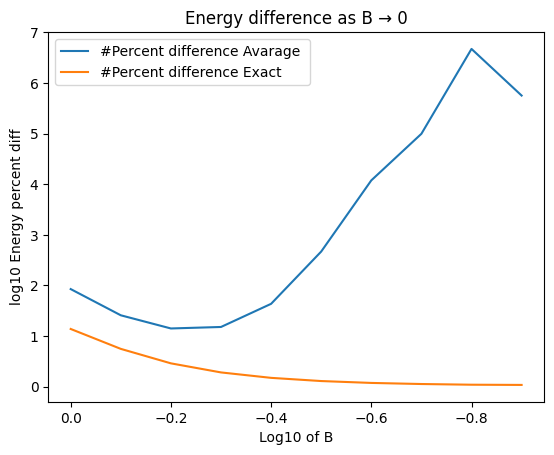

In [ ]:
plt.plot((x), y_CC, label=f"#Percent difference Avarage ")
plt.plot((x), y_ED_avg, label=f"#Percent difference Exact")
plt.plot((x), y_ED_1, label=f"#Percent difference Exact")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B → 0")
plt.xlabel("g")
plt.ylabel("log10 Energy percent diff")
plt.legend()

# x0 = x[0]
# y0 = np.log10(y_bigger_basis)[0]

# plt.annotate(
#     f"y({x_bigger_basis[0]}) = {y_bigger_basis[0]:.3f} %",
#     xy=(x0, y0),                  # point to (x=0, y=y0)
#     xytext=(0.3, y0 -8),      # position of text box
#     textcoords='data',
#     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
#     bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="black", lw=0.8),
#     fontsize=10
# )
plt.show()

# Calculate times

In [2]:
g = 0.2

Change site

In [3]:
state = 11

In [4]:
site = 10

In [5]:
str_fast_d_site_1 = time.perf_counter()
_, _, _, _, _, n_iter_fast_d_site_1 = t_periodic_fast_d(site, state, g, True, Import=False)
end_fast_d_site_1 = time.perf_counter()

Done.


In [6]:
str_fast_s_site_1 = time.perf_counter()
_, _, _, _, _, n_iter_fast_s_site_1 = t_periodic_fast_s(site, state, g, True)
end_fast_s_site_1 = time.perf_counter()

Done.


/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [7]:
site = 100

In [8]:
str_fast_d_site_2 = time.perf_counter()
_, _, _, _, _, n_iter_fast_d_site_2 = t_periodic_fast_d(site, state, g, True, Import=False)
end_fast_d_site_2 = time.perf_counter()

Done.


In [9]:
str_fast_s_site_2 = time.perf_counter()
_, _, _, _, _, n_iter_fast_s_site_2 = t_periodic_fast_s(site, state, g, True)
end_fast_s_site_2 = time.perf_counter()

Done.


Change state

In [19]:
site = 3

In [20]:
state = 11

In [21]:
str_fast_d_state_1 = time.perf_counter()
_, _, _, _, _, n_iter_fast_d_state_1 = t_periodic_fast_d(site, state, g, True, Import=False)
end_fast_d_state_1 = time.perf_counter()

Done.


In [22]:
str_fast_s_state_1 = time.perf_counter()
_, _, _, _, _, n_iter_fast_s_state_1 = t_periodic_fast_s(site, state, g, True)
end_fast_s_state_1 = time.perf_counter()

Done.


/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [25]:
state = 151

In [26]:
str_fast_s_state_2 = time.perf_counter()
_, _, _, _, _, n_iter_fast_s_state_2 = t_periodic_fast_s(site, state, g, True)
end_fast_s_state_2 = time.perf_counter()

Done.


/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [27]:
str_fast_d_state_2 = time.perf_counter()
_, _, _, _, _, n_iter_fast_d_state_2 = t_periodic_fast_d(site, state, g, True, Import=False)
end_fast_d_state_2 = time.perf_counter()

Done.


In [28]:
print("State Dense: ")
print(f"Site 10: {(str_fast_d_site_1 - end_fast_d_site_1) / n_iter_fast_d_site_1}")
print(f"Site 100: {(str_fast_d_site_2 - end_fast_d_site_2) / n_iter_fast_d_site_2}")

print("\n")

print("State Sparse: ")
print(f"Site 10: {(str_fast_s_site_1 - end_fast_s_site_1) / n_iter_fast_s_site_1}")
print(f"Site 100: {(str_fast_s_site_2 - end_fast_s_site_2) / n_iter_fast_s_site_2}")

print("\n\n")

print("State Dense: ")
print(f"State 11: {(str_fast_d_state_1 - end_fast_d_state_1) / n_iter_fast_d_state_1}")
print(f"State 101: {(str_fast_d_state_2 - end_fast_d_state_2) / n_iter_fast_d_state_2}")

print("\n")

print("State Sparse: ")
print(f"State 11: {(str_fast_s_state_1 - end_fast_s_state_1) / n_iter_fast_s_state_1}")
print(f"state 101: {(str_fast_s_state_2 - end_fast_s_state_2) / n_iter_fast_s_state_2}")

State Dense: 
Site 10: -0.0023196973672479785
Site 100: -0.09212887444606933


State Sparse: 
Site 10: -0.07228789473638723
Site 100: -2.6106841118430326



State Dense: 
State 11: -0.0008952354158585271
State 101: -11.418306012294392


State Sparse: 
State 11: -0.017463309015147387
state 101: -5.850624644113552


## Non Linear

Change site

In [29]:
site = 5

In [30]:
state = 11

In [31]:
str_slow_np_state_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_state_1 = t_non_periodic(site, state, g)
end_slow_np_state_1 = time.perf_counter()

In [32]:
str_slow_p_state_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_state_1 = t_periodic(site, state, g)
end_slow_p_state_1 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [35]:
state = 15

In [36]:
str_slow_np_state_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_state_2 = t_non_periodic(site, state, g)
end_slow_np_state_2 = time.perf_counter()

In [37]:
str_slow_p_state_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_state_2 = t_periodic(site, state, g)
end_slow_p_state_2 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


Change state

In [38]:
state = 5

In [39]:
site = 11

In [40]:
str_slow_np_site_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_site_1 = t_non_periodic(site, state, g)
end_slow_np_site_1 = time.perf_counter()

In [41]:
str_slow_p_site_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_site_1 = t_periodic(site, state, g)
end_slow_p_site_1 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [46]:
site = 21

In [47]:
str_slow_np_site_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_site_2 = t_non_periodic(site, state, g)
end_slow_np_site_2 = time.perf_counter()

In [48]:
str_slow_p_site_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_site_2 = t_periodic(site, state, g)
end_slow_p_site_2 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [45]:
print("State Non-Linear: ")
print(f"Site 10: {(str_slow_np_site_1 - end_slow_np_site_1) / n_iter_slow_np_site_1}")
print(f"Site 100: {(str_slow_np_site_2 - end_slow_np_site_2) / n_iter_slow_np_site_2}")

print("\n")

print("State Linear: ")
print(f"Site 10: {(str_slow_p_site_1 - end_slow_p_site_1) / n_iter_slow_p_site_1}")
print(f"Site 100: {(str_slow_p_site_2 - end_slow_p_site_2) / n_iter_slow_p_site_2}")

print("\n\n")

print("State Non-Linear: ")
print(f"State 11: {(str_slow_np_state_1 - end_slow_np_state_1) / n_iter_slow_np_state_1}")
print(f"State 101: {(str_slow_np_state_2 - end_slow_np_state_2) / n_iter_slow_np_state_2}")

print("\n")

print("State Linear: ")
print(f"State 11: {(str_slow_p_state_1 - end_slow_p_state_1) / n_iter_slow_p_state_1}")
print(f"State 101: {(str_slow_p_state_2 - end_slow_p_state_2) / n_iter_slow_p_state_2}")

State Non-Linear: 
Site 10: -0.08192406874732114
Site 100: -0.2437511739495676


State Linear: 
Site 10: -0.015653620396430295
Site 100: -0.031536469882768065



State Non-Linear: 
State 11: -0.21281027054886192
State 101: -1.1986117497225905


State Linear: 
State 11: -0.0806438405594478
State 101: -0.4851236672264834


# Remove Field

In [ ]:
site = 2
state = 21
state_NO = 5

g = 1
D_val = 1e-4
lambda_val = -1e-2

periodic = False

In [ ]:
H_K_V = hamiltonian_dense(state, site, g, D=D_val, lambda_val=lambda_val, field=True, periodic=periodic)
H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

H_L, K_L, V_L = H_K_V[0], H_K_V[1], H_K_V[2]

eig_val_L, eig_vec_L = np.linalg.eigh(H_L)

In [ ]:
# state_NO = state

In [ ]:
D = density_matrix_1(state, site, eig_vec_L[:, np.argmin(eig_val_L)], 0)

# Extract eigenstates and eigenvalues.
eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)

# Create a list of indecies associated to eigenstates in decreasing order.
index_d = np.argsort(-eig_val_D)

# Makes a change of basis matrix.
matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

In [ ]:
K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO

matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)

V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

In [ ]:
H_NO, _, _ = hamiltonian_dense(state_NO, site, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)

In [ ]:
eig_val_NO, eig_vec_NO = np.linalg.eigh(H_NO)
eig_val, eig_vec = np.linalg.eigh(H)

In [ ]:
K_loc = matrix_p_to_NO @ K_NO @ matrix_p_to_NO.T.conj()

V_loc = matrix_p_to_NO_V @ V_NO @ matrix_p_to_NO_V.conj().T

In [ ]:
H_loc, _, _ = hamiltonian_dense(state_NO, site, 1, K_import=K_loc, V_import=V_loc, Import_K_V=True, periodic=periodic)

In [ ]:
eig_val_loc, eig_vec_loc = np.linalg.eigh(H_loc)

In [ ]:
D_loc = density_matrix_1(state_NO, site, eig_vec_loc[:, np.argmin(eig_val_loc)], 0)

In [ ]:
eig_val_D_loc, eig_vec_D_loc = np.linalg.eigh(D_loc)

In [ ]:
-np.sort(-eig_val_D_loc)

array([0.893998199773, 0.102640877322, 0.001847945725, 0.001426363368, 0.000081717768, 0.000004896043])

In [ ]:
eig_vec_D_loc[: ,np.argsort(-eig_val_D_loc)]

array([[-0.600629180692-0.j,  0.085724998575+0.j,  0.120368348094+0.j,  0.560414801086+0.j,  0.049377856802+0.j, -0.548547491726+0.j],
       [-0.404680336047+0.j,  0.234399767352+0.j,  0.517050140661+0.j, -0.164243994695+0.j,  0.514281340205+0.j,  0.471686696916+0.j],
       [-0.130817372   +0.j,  0.204283660793+0.j,  0.491080751087+0.j, -0.52274159636 +0.j, -0.578616462209+0.j, -0.303214297362+0.j],
       [-0.326317276333+0.j, -0.914851134619+0.j,  0.071527802713+0.j, -0.226273104944+0.j,  0.015767554461+0.j,  0.000276221337+0.j],
       [-0.530992865602+0.j,  0.136031745397+0.j, -0.427269923087+0.j,  0.046212195098+0.j, -0.503957394084+0.j,  0.510757997217+0.j],
       [-0.264440617052+0.j,  0.201293132891+0.j, -0.537898219922+0.j, -0.576511317642+0.j,  0.379549534593+0.j, -0.35184455535 +0.j]])

In [ ]:
y_L, x_L = curve(D_loc)

In [ ]:
def calculate_xy(i):
    """Your calculation per frame. Modify this part only."""

    site = 2
    state = 21
    state_NO = 5

    g = 1
    D_val = 1e-4
    lambda_val = -1e-2

    periodic = False

    H_K_V = hamiltonian_dense(state, site, g, D=D_val, lambda_val=lambda_val, field=True, periodic=periodic)
    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    H_L, K_L, V_L = H_K_V[0], H_K_V[1], H_K_V[2]

    eig_val_L, eig_vec_L = np.linalg.eigh(H_L)

    D = density_matrix_1(state, site, eig_vec_L[:, np.argmin(eig_val_L)], 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    K_loc = matrix_p_to_NO @ K_NO @ matrix_p_to_NO.T.conj()
    V_loc = matrix_p_to_NO_V @ V_NO @ matrix_p_to_NO_V.conj().T

    H_loc, _, _ = hamiltonian_dense(state_NO, site, 1, K_import=K_loc, V_import=V_loc, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_loc)

    D_loc = density_matrix_1(state_NO, site, eig_vec_loc[:, np.argmin(eig_val_loc)], 0)
    y, x = curve(D_loc)

    return x, y

In [ ]:
# x, y = calculate_xy(20)

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


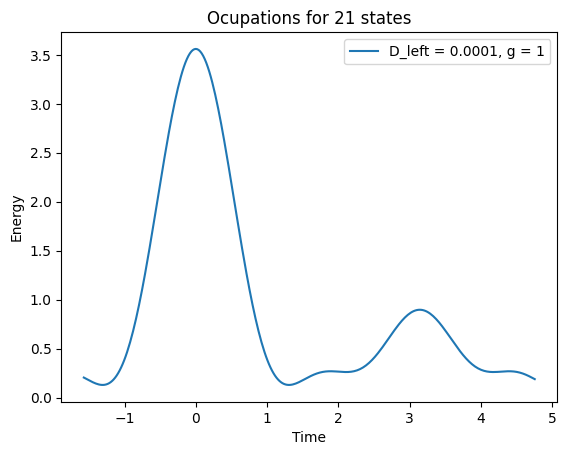

In [ ]:
plt.plot(x_L, y_L, label=f"D_left = {D_val}, g = {g}")
# plt.plot(x, y, label=f"D_left = {D_val}, g = {g}")
# plt.plot(np.ones((20))* np.pi, np.arange(20), label=f"pi")
plt.title(f"Ocupations for {state} states")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [ ]:
# time, energy, t_1_max, t_2_max = integration_scheme_fast(site, state_NO, 1, t_init=0, t_final=100, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

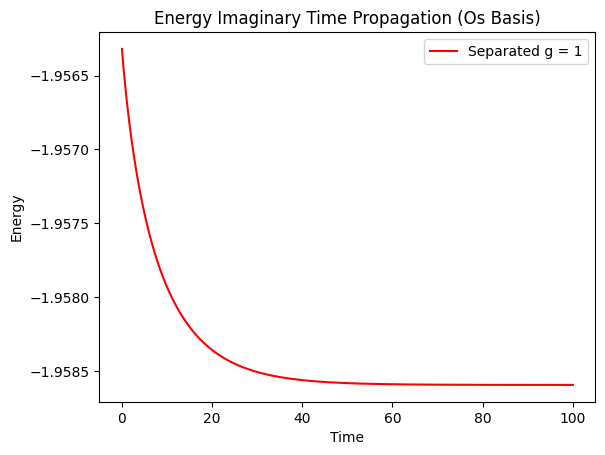

In [ ]:
plt.plot(time, energy, label=f"Separated g = {g}", color = "red")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

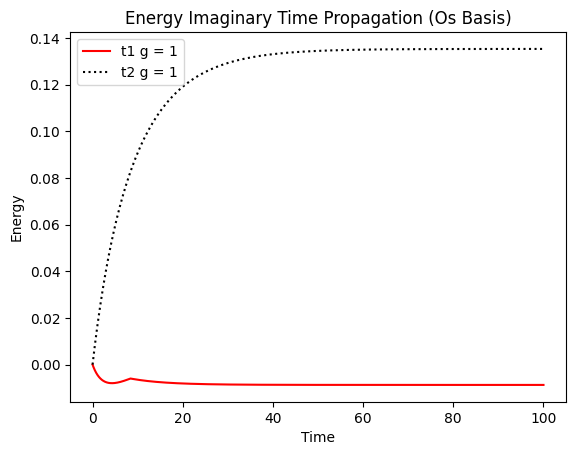

In [ ]:
plt.plot(time, t_1_max, label=f"t1 g = {g}", color = "red")
plt.plot(time, t_2_max, label=f"t2 g = {g}", color = "black", linestyle=':')
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [ ]:
np.min(eig_val_NO)

np.float64(-1.9586036848314958)

In [ ]:
energy[-1]

np.complex128(-1.958594663718827+0j)

In [ ]:
np.min(eig_val_NO) - energy[-1]

np.complex128(-9.021112668872178e-06+0j)

# No Field

In [ ]:
def calculate_xy_no_field(site, state, state_NO, final, num):
    """Your calculation per frame. Modify this part only."""

    site_i = site

    g = 1
    D_val = 1 * 10**(-num)

    if site_i == 2:
        periodic = False
    else:
        periodic = True

    H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

    eig_val, eig_vec = np.linalg.eigh(H)

    int_1_2 = np.argsort(eig_val)

    psi_1 = eig_vec[:, int_1_2[0]]
    psi_2 = eig_vec[:, int_1_2[1]]

    pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

    D = density_matrix_1(state, site, pci_loc, 0)

    eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
    index_d = np.argsort(-eig_val_D)
    matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

    K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
    matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
    V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

    H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
    eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

    print("ED done.")

    time, energy, t_1_max, t_2_max = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

    E_CC = np.abs(energy[-1].real)
    E_ED = np.abs(np.min(eig_val_loc).real)

    per_diff = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200

    print(E_CC.real, E_ED.real)

    return (np.log10(D_val)).real, per_diff

In [ ]:
site = 2
state = 11
state_NO = 5
final = 400

In [ ]:
n = 15
x = np.zeros((n))
y = np.zeros((n))

for i in range(n):
    x[i], y[i] = calculate_xy_no_field(site, state, state_NO, final, i)
    print(x[i], y[i])

ED done.
0.36318830298424654 0.5129981200262083
0.0 34.19587729452278
ED done.
1.4183415926247283 1.415356791394682
-1.0 0.21066470919268737
ED done.
1.7915464437040594 1.7913841586077273
-2.0 0.0090587909365246
ED done.
1.864170598252051 1.8641687564980147
-3.0 9.879755359837557e-05
ED done.
1.8723823093998875 1.8723822960783498
-4.0 7.114753024144519e-07
ED done.
1.8732144694443462 1.8732144698721371
-5.0 2.283726293668918e-08
ED done.
1.8732977970513474 1.8732977971117815
-6.0 3.2260808858688562e-09
ED done.
1.8733061309298114 1.8733061309360313
-7.0 3.320286722204027e-10
ED done.
1.8733069643288385 1.873306964329462
-8.0 3.328345340630119e-11
ED done.
1.8733070476688543 1.8733070476689155
-9.0 3.2714504029422148e-12
ED done.
1.8733070560028593 1.873307056002866
-10.0 3.5559243352045325e-13
ED done.
1.8733070568362566 1.873307056836258
-11.0 7.111848667245154e-14
ED done.
1.8733070569195982 1.873307056919598
-12.0 1.185308111154793e-14
ED done.
1.8733070569279315 1.873307056927931
-

In [ ]:
site = 2
state = 21
state_NO = 5
final = 400

In [ ]:
x_bigger_basis = np.zeros((n))
y_bigger_basis = np.zeros((n))

for i in range(n):
    x_bigger_basis[i], y_bigger_basis[i] = calculate_xy_no_field(site, state, state_NO, final, i)
    print(x_bigger_basis[i], y_bigger_basis[i])

ED done.
0.36318830294314197 0.5129981196637219
0.0 34.19587723691493
ED done.
1.4184233538349007 1.415397381525284
-1.0 0.21356130766204207
ED done.
1.810206036244144 1.8093513150346971
-2.0 0.04722794123677887
ED done.
1.9392808674672037 1.9390705529771457
-3.0 0.01084556128407481
ED done.
1.9756244237481506 1.9756197877662072
-4.0 0.00023465934755114836
ED done.
1.9811683154151796 1.9811682677656275
-5.0 2.4051239000779926e-06
ED done.
1.9817568297061445 1.9817568296348669
-6.0 3.5966900369111125e-09
ED done.
1.9818160471238362 1.9818160471688073
-7.0 2.2691883027908557e-09
ED done.
1.9818219725516344 1.9818219725611423
-8.0 4.797580264298595e-10
ED done.
1.9818225651313046 1.9818225651367942
-9.0 2.769979948830704e-10
ED done.
1.9818226243896337 1.981822624394717
-10.0 2.56494555970052e-10
ED done.
1.9818226303154796 1.9818226303205217
-11.0 2.5442180402534545e-10
ED done.
1.9818226309080706 1.981822630913109
-12.0 2.542313349221813e-10
ED done.
1.9818226309673181 1.981822630972355

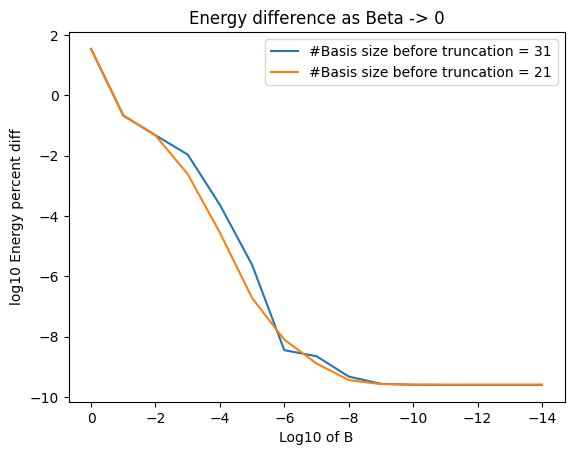

In [ ]:
plt.plot(x_bigger_basis, np.log10(y_bigger_basis), label=f"#Basis size before truncation = {31}, NO = {state_NO}")
plt.plot((x), np.log10(y), label=f"#Basis size before truncation = {21}, NO = {state_NO}")
plt.gca().invert_xaxis()
plt.title(f"Energy difference as B /> 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()
plt.show()

In [ ]:
site = 2
state = 21
state_NO = 5
final = 10

In [ ]:
site_i = site

g = 1
D_val = 1

if site_i == 2:
    periodic = False
else:
    periodic = True

H, K, V = hamiltonian_dense(state, site, g, D=D_val, periodic=periodic)

eig_val, eig_vec = np.linalg.eigh(H)

int_1_2 = np.argsort(eig_val)

psi_1 = eig_vec[:, int_1_2[0]]
psi_2 = eig_vec[:, int_1_2[1]]

pci_loc = (psi_1 + psi_2) * (1/np.sqrt(2))

D = density_matrix_1(state, site, pci_loc, 0)

eig_val_D, matrix_p_to_NO_full = np.linalg.eigh(D)
index_d = np.argsort(-eig_val_D)
matrix_p_to_NO = matrix_p_to_NO_full[:, index_d[:state_NO]]

K_NO = matrix_p_to_NO.T.conj() @ K @ matrix_p_to_NO
matrix_p_to_NO_V = np.kron(matrix_p_to_NO, matrix_p_to_NO)
V_NO = matrix_p_to_NO_V.conj().T @ V @ matrix_p_to_NO_V

H_NO, _, _ = hamiltonian_dense(state_NO, site_i, 1, K_import=K_NO, V_import=V_NO, Import_K_V=True, periodic=periodic)
eig_val_loc, eig_vec_loc = np.linalg.eigh(H_NO)

print("ED done.")

time, energy, t_1_max, t_2_max = integration_scheme_fast(site_i, state_NO, 1, t_init=0, t_final=final, nof_points=100000, Import=True, K_import=K_NO, V_import=V_NO.reshape(state_NO, state_NO, state_NO, state_NO))

E_CC = np.abs(energy[-1].real)
E_ED = np.abs(np.min(eig_val_loc).real)

per_diff = (np.abs(E_CC - E_ED) / (E_CC + E_ED)) * 200

print(E_CC.real, E_ED.real)

ED done.
19149
0.36294525010847356 0.5129981196637204


In [ ]:
per_diff

np.float64(34.26086085776779)

In [ ]:
-np.sort(-eig_val_D)

array([ 0.974383552232,  0.017221100642,  0.007312122036,  0.001042834149,  0.00004007543 ,  0.000000249166,  0.000000065279,  0.000000001061,  0.000000000006,  0.            ,  0.            ,  0.            ,  0.            ,  0.            ,  0.            ,  0.            ,  0.            ,  0.            ,  0.            , -0.            , -0.            ])

In [ ]:
per_diff

np.float64(3.395727496658453e-14)

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


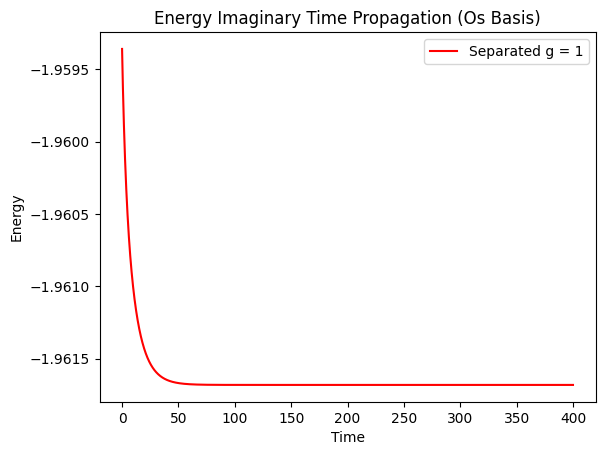

In [ ]:
plt.plot(time, energy, label=f"Separated g = {g}", color = "red")
plt.title("Energy Imaginary Time Propagation (Os Basis)")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

# Graphs

## ED NO comparison.

In [ ]:
def g_ground_ED_NO(state, state_NO, site, g):

    H, _, _ = hamiltonian_sparse(state, site, g)
    eig_val, _ = sp.linalg.eigsh(H, k=1, which='SA', tol=1e-19, maxiter=2000)

    H_NO_5, _, _ = hamiltonian_general_sparse(state, state_NO, site, g)
    eig_val_NO_5, _ = sp.linalg.eigsh(H_NO_5, k=1, which='SA', tol=1e-19, maxiter=2000)

    H_NO_7, _, _ = hamiltonian_general_sparse(state, state_NO+2, site, g)
    eig_val_NO_7, _ = sp.linalg.eigsh(H_NO_7, k=1, which='SA', tol=1e-19, maxiter=2000)

    return eig_val, eig_val_NO_5, eig_val_NO_7

In [ ]:
state = 11
state_NO = 5
site = 5

In [ ]:
n = 21
E_ED_arr = np.zeros((n -1))
E_NO_5_arr = np.zeros((n-1))
E_NO_7_arr = np.zeros((n-1))
g_arr = np.zeros((n-1))

for i in range(1, n):

    g = i / 10

    E_ED_arr[i-1], E_NO_5_arr[i-1], E_NO_7_arr[i-1] = g_ground_ED_NO(state, state_NO, site, g)

    g_arr[i-1] = g
    print(E_ED_arr[i-1], E_NO_5_arr[i-1], E_NO_7_arr[i-1])

    print("g:", g)

Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 0
Finished site 1
Finished site 2
[0.992859706572 0.006034994913 0.001102349658 0.000002020617 0.000000927993 0.000000000142 0.000000000104 0.             0.             0.             0.            ]
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4


/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/quant_rotor/models/sparse/support_ham.py:313: ComplexWarning: Casting complex values to real discards the imaginary part
  data = np.asarray(data, dtype=np.float64)


Finished site 0
Finished site 1
Finished site 2
[0.992859706572 0.006034994913 0.001102349658 0.000002020617 0.000000927993 0.000000000142 0.000000000104 0.             0.             0.             0.            ]
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4


/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_38180/3060431231.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  E_ED_arr[i-1], E_NO_5_arr[i-1], E_NO_7_arr[i-1] = g_ground_ED_NO(state, state_NO, site, g)


-0.03137634218679854 -0.03137632613996759 -0.03137634218582129
g: 0.1
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 0
Finished site 1
Finished site 2
[0.968213425593 0.028075050462 0.003663137772 0.000033663164 0.000014706684 0.000000009633 0.000000006689 0.000000000001 0.000000000001 0.             0.            ]
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 0
Finished site 1
Finished site 2
[0.968213425593 0.028075050462 0.003663137772 0.000033663164 0.000014706684 0.000000009633 0.000000006689 0.000000000001 0.000000000001 0.             0.            ]
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
-0.1277277904813122 -0.1277266464382759 -0.1277277901763583
g: 0.2
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 0
Finished site 1
Finished site 2
[0.924044993095 0.069327111178 0.006401170057 0.00015761574  0.00

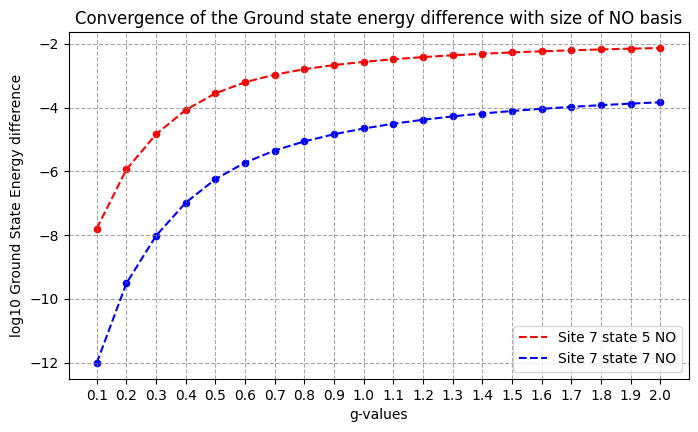

In [ ]:
plt.figure(figsize=(8, 4.5))

plt.scatter(g_arr, np.log10(np.abs(E_ED_arr - E_NO_5_arr)), color = "red", s=20)
plt.scatter(g_arr, np.log10(np.abs(E_ED_arr - E_NO_7_arr)), color = "blue", s=20)
plt.plot(g_arr, np.log10(np.abs(E_ED_arr - E_NO_5_arr)), label=f"Site 7 state 5 NO", color = "red", linestyle = "--")
plt.plot(g_arr, np.log10(np.abs(E_ED_arr - E_NO_7_arr)), label=f"Site 7 state 7 NO", color = "blue", linestyle = "--")
plt.title("Convergence of the Ground state energy difference with size of NO basis")
plt.xlabel("g-values")
plt.ylabel("log10 Ground State Energy difference")
plt.legend()
plt.xticks(g_arr)   # grid at each x value
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
plt.show()

In [ ]:
np.log10(np.abs(E_ED_arr - E_NO_5_arr))

array([-7.794610722446, -5.941557638062, -4.835706326547, -4.074882686784, -3.553081473882, -3.204334221009, -2.966403305107, -2.795592838992, -2.666702356703, -2.565561097092, -2.483842850499, -2.416367110651, -2.359730199093, -2.311584638251, -2.270242054571, -2.234444787104, -2.203229047465, -2.175839498984, -2.151673679146, -2.130244353992])

## NO_CC_Comparison

In [ ]:
def g_ground_ED_CCC(state, site, g):

    time, energy, t_1_max, t_2_max = integration_scheme_fast(site, state, g, t_init=0, t_final=400, nof_points=100000)

    E_CCC = np.abs(energy[-1].real)

    return E_CCC

In [ ]:
site = 9
state = 21

In [ ]:
n = 10
E_CCC = np.zeros((n))

for i in range(1, n):

    g = i / 10

    E_CCC[i] = g_ground_ED_CCC(site, state, g)
    print(E_CCC[i])

[4.+0.j 1.+0.j 0.+0.j 1.+0.j 4.+0.j]


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x107fad2b0>>
Traceback (most recent call last):
  File "/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


## Iteration Counter Graph

In [ ]:
state = 5
g = 0.2

In [ ]:
n = 10
state_11 = np.zeros((n -1))
state_5 = np.zeros((n -1))
time_arr = np.zeros((n-1))

for i in range(3, n * 10 + 3, 10):

    start = time.perf_counter()
    _, _, _, _, n_iterations = integration_scheme_fast(i, state, g, t_init=0, t_final=10, nof_points=10000)
    end = time.perf_counter()

    time_arr[(i - 3)//10] = (end - start) / n_iterations
    state_5[(i - 3)//10] = i

    print("Time:", end - start, "Per-iter:", (end - start) / n_iterations)

Time: 2.5166429579257965 Per-iter: 0.0005049444137090282
Time: 26.56466395780444 Per-iter: 0.004270159774602868
Time: 77.26242029108107 Per-iter: 0.010359670191885368
Time: 148.57387783308513 Per-iter: 0.017087277496617037
Time: 252.4007870000787 Per-iter: 0.025412886327031686
Time: 426.71433166693896 Per-iter: 0.03820524054677581
Time: 549.3382150419056 Per-iter: 0.04428004312767255
Time: 698.4353398331441 Per-iter: 0.051193677331462586
Time: 952.5224347920157 Per-iter: 0.06396202221273273


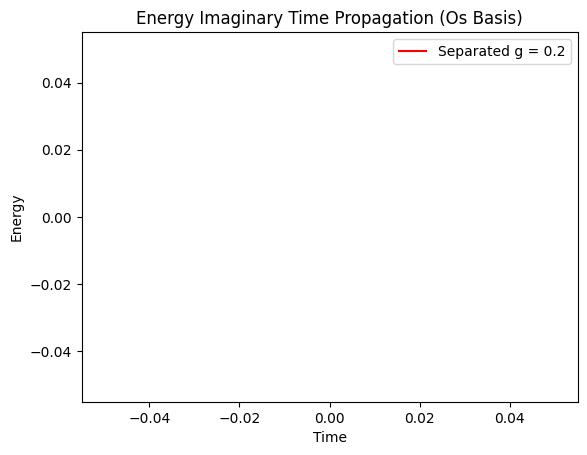

In [ ]:
plt.plot(state_5, time_arr, label=f"Separated g = {g}", color = "red")
plt.title("Efficency")
plt.xlabel("n-site")
plt.ylabel("Time per Iteration")
plt.legend()
plt.show()

# Graph lot sites

In [ ]:
site = 5
state = 7
state_NO = 5
final = 100

g = 0.2

In [ ]:
one_max_d, two_max_d, energy, t_a_i_tensor_d, t_ab_ij_tensor_d = t_periodic_fast(site, state, g, True, Import=False)

Done.


In [ ]:
one_max_d, two_max_d, energy, t_a_i_tensor_d, t_ab_ij_tensor_d = t_periodic(site, state, g)

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [ ]:
H_s, _, _ = hamiltonian_sparse(state, site, g)

eig_val_s, _ = sp.linalg.eigsh(H_s, k=1, which='SA', tol=1e-19, maxiter=2000)

Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4


In [ ]:
print(eig_val_s/5)
print(energy/5)

[-0.025544822074]
(-0.02613362392284113+0j)


In [ ]:
eig_val_s/5 - energy/5

array([0.000588801849+0.j])

In [ ]:
def sites_CCC_func(site):

    one_max_d, two_max_d, energy, t_a_i_tensor_d, t_ab_ij_tensor_d, _ = t_periodic_fast(site, state, g, True, Import=False)

    return energy.real

In [ ]:
def sites_NO_func(site):

    H_NO, _, _ = hamiltonian_general_sparse(state, state_NO, site, g)
    print("Ham_Done")
    eig_val_NO, _ = sp.linalg.eigsh(H_NO, k=5, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val_NO)

In [ ]:
def sites_ED_func(site):

    H, _, _ = hamiltonian_sparse(state, site, g)

    eig_val, _ = sp.linalg.eigsh(H, k=1, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val)

In [ ]:
n_CCC = 30
n_ED = 9
n_NO = 11

E_ED = np.zeros((n_ED))
E_NO = np.zeros((n_NO))
E_CCC = np.zeros((n_CCC))

sites_CCC = np.zeros((n_CCC))
sites_ED = np.zeros((n_ED))
sites_NO = np.zeros((n_NO))

In [ ]:
for i in range(3, n_ED):

    E_ED[i - 3] = sites_ED_func(i)

    sites_ED[i-3] = i
    print(E_ED[i-3], sites_ED[i-3])

Finished site 0
Finished site 1
Finished site 2
-0.08587361259502248 3.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.10517252283924748 4.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
-0.127727788407429 5.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 5
-0.1521935410448537 6.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 5
Finished site 6
-0.17716120327999627 7.0
Finished site 0
Finished site 1
Finished site 2
Finished site 3
Finished site 4
Finished site 5
Finished site 6
Finished site 7
-0.20233302738080047 8.0


In [ ]:
for i in range(3, n_CCC):

    E_CCC[i - 3] = sites_CCC_func(i)

    sites_CCC[i-3] = i
    print(E_CCC[i-3], sites_CCC[i-3])

Done.
-0.08793496254908299 3.0
Done.
-0.10783521474837554 4.0
Done.
-0.130669004557344 5.0
Done.
-0.15551413467794759 6.0
Done.
-0.18091824558487002 7.0
Done.
-0.2065706412362802 8.0
Done.
-0.23231449518750136 9.0
Done.
-0.25809627140077623 10.0
Done.
-0.28389325535905285 11.0
Done.
-0.30969654080287556 12.0
Done.
-0.33550243200735475 13.0
Done.
-0.36130941312788223 14.0
Done.
-0.3871168515749352 15.0
Done.
-0.41292448297565754 16.0
Done.
-0.43873219605450803 17.0
Done.
-0.4645399438267875 18.0
Done.
-0.4903477063746164 19.0
Done.
-0.5161554752306265 20.0
Done.
-0.5419632467854396 21.0
Done.
-0.5677710194970361 22.0
Done.
-0.5935787927052861 23.0
Done.
-0.6193865661270864 24.0
Done.
-0.6451943396408306 25.0
Done.
-0.6710021131942102 26.0
Done.
-0.6968098867646956 27.0
Done.
-0.7226176603425712 28.0
Done.
-0.7484254339236397 29.0


In [ ]:
n = 5

In [ ]:
E_CCC[n]/ sites_CCC[n] - E_ED[n]/ sites_CCC[n]

np.float64(-0.0005297017319349645)

In [ ]:
corection = np.ones(sites_CCC.shape) * E_CCC[n]/ sites_CCC[n] - E_ED[n]/ sites_CCC[n]

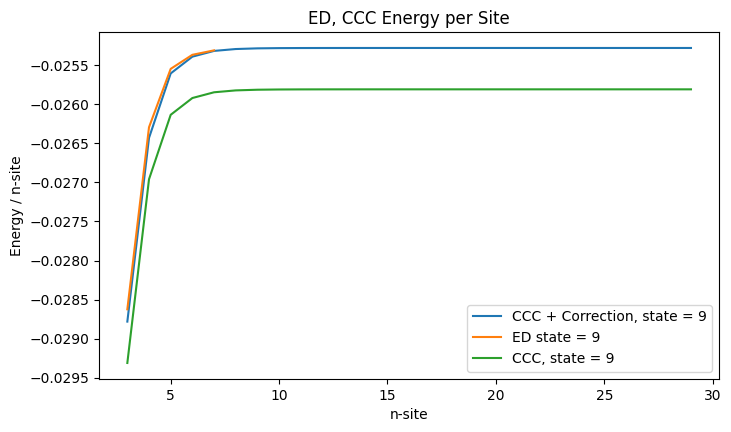

In [ ]:
plt.figure(figsize=(8, 4.5))

plt.plot(sites_CCC[:27], (E_CCC[:27]/sites_CCC[:27])- corection[:27], label=f"CCC + Correction, state = 9")
plt.plot(sites_ED[:5], E_ED[:5]/sites_ED[:5], label=f"ED state = 9")
plt.plot(sites_CCC[:27], (E_CCC[:27]/sites_CCC[:27]), label=f"CCC, state = 9")
plt.title(f"ED, CCC Energy per Site")
plt.xlabel("n-site")
plt.ylabel("Energy / n-site")
plt.legend()
plt.show()

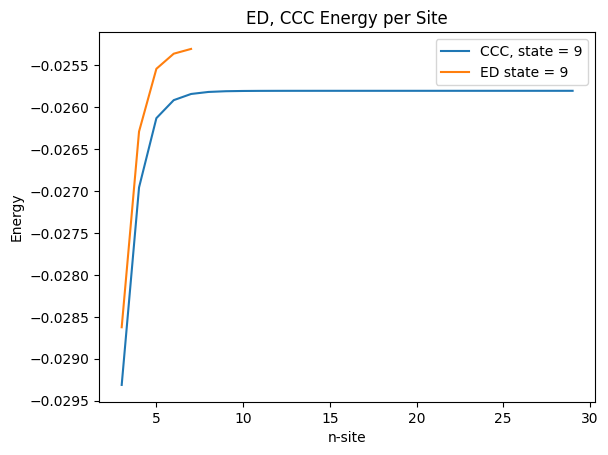

In [ ]:
plt.plot(sites_CCC[:27], E_CCC[:27]/(sites_CCC[:27] ), label=f"CCC, state = 9")
plt.plot(sites_ED[:5], E_ED[:5]/sites_ED[:5], label=f"ED state = 9")
plt.title(f"ED, CCC Energy per Site")
plt.xlabel("n-site")
plt.ylabel("Energy")
plt.legend()
plt.show()

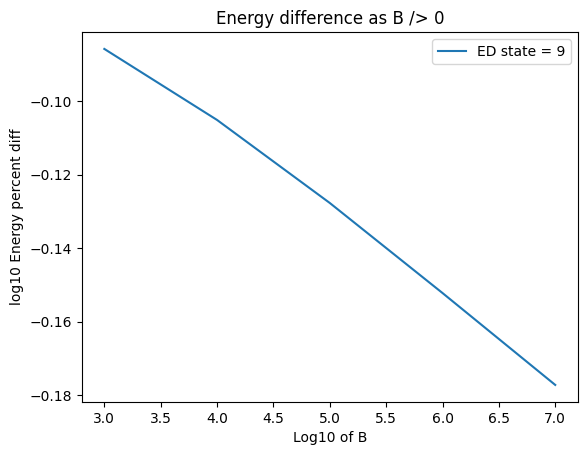

In [ ]:
plt.plot(sites_ED[:5], E_ED[:5], label=f"ED state = 9")
plt.title(f"Energy difference as B /> 0")
plt.xlabel("Log10 of B")
plt.ylabel("log10 Energy percent diff")
plt.legend()
plt.show()

# Small g Graph

In [ ]:
site = 4
state = 7

In [ ]:
def sites_CCC_func(g):

    _, _, energy, _, _, _ = t_periodic_fast(site, state, g, True, Import=False)

    return energy.real

In [ ]:
def g_ground_ED_CCC(g):

    _, energy, _, _, _ = integration_scheme_fast(site, state, g, t_init=0, t_final=10, nof_points=100000)

    E_CCC = np.abs(energy[-1].real)

    return E_CCC

In [ ]:
def sites_ED_func(g):

    H, _, _ = hamiltonian_sparse(state, site, g)

    eig_val, _ = sp.linalg.eigsh(H, k=1, which='SA', tol=1e-19, maxiter=2000)

    return np.min(eig_val)

In [ ]:
n = 10

E_ED = np.zeros((n))
E_CCC = np.zeros((n))

g_arr =  np.zeros((n))

In [ ]:
for i in range(1, n+1):

    E_ED[i-1] = sites_ED_func(i/10)
    E_CCC[i - 1] = g_ground_ED_CCC(i/10)

    g_arr[i-1] = i/10
    print(E_ED[i-1], g_arr[i-1])

Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.02533024138374832 0.1
Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.10517252283924608 0.2
Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.24980954378802342 0.3
Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.47032037999705084 0.4
Finished site 0
Finished site 1
Finished site 2
Finished site 3
-0.7688253242656794 0.5
Finished site 0
Finished site 1
Finished site 2
Finished site 3


In [ ]:
g_arr

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [ ]:
E_ED

array([-0.03137634218 , -0.127727788407, -0.298328041547, -0.560402258914, -0.926258100549, -1.385401983436, -1.912899522504, -2.487444143664, -3.09552813379 , -3.72897932439 ])

In [ ]:
E_CCC = np.abs(E_CCC)
E_ED = np.abs(E_ED)

In [ ]:
per_diff_1 = (np.abs(E_CCC - E_ED) / (E_CCC + E_ED)) * 200

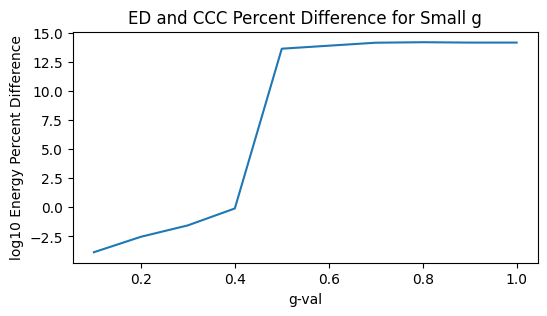

In [ ]:
plt.figure(figsize=(6, 3))

plt.plot(g_arr, np.log10(np.abs(E_ED - E_CCC)))
plt.title(f"ED and CCC Percent Difference for Small g")
plt.xlabel("g-val")
plt.ylabel("log10 Energy Percent Difference")
plt.show()

## Non Linear

Change site

In [ ]:
g=0.2

In [ ]:
site = 5

In [ ]:
state = 11

In [ ]:
str_slow_np_state_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_state_1 = t_non_periodic(site, state, g)
end_slow_np_state_1 = time.perf_counter()

In [ ]:
str_slow_p_state_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_state_1 = t_periodic(site, state, g)
end_slow_p_state_1 = time.perf_counter()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [ ]:
state = 31

In [ ]:
str_slow_np_state_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_state_2 = t_non_periodic(site, state, g)
end_slow_np_state_2 = time.perf_counter()

In [ ]:
str_slow_p_state_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_state_2 = t_periodic(site, state, g)
end_slow_p_state_2 = time.perf_counter()

Change state

In [ ]:
state = 5

In [ ]:
site = 11

In [ ]:
str_slow_np_site_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_site_1 = t_non_periodic(site, state, g)
end_slow_np_site_1 = time.perf_counter()

In [ ]:
str_slow_p_site_1 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_site_1 = t_periodic(site, state, g)
end_slow_p_site_1 = time.perf_counter()

In [ ]:
site = 30

In [ ]:
str_slow_np_site_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_np_site_2 = t_non_periodic(site, state, g)
end_slow_np_site_2 = time.perf_counter()

In [ ]:
str_slow_p_site_2 = time.perf_counter()
_, _, _, _, _ , n_iter_slow_p_site_2 = t_periodic(site, state, g)
end_slow_p_site_2 = time.perf_counter()

In [ ]:
print("State Non-Linear: ")
print(f"Site 10: {(str_slow_np_site_1 - end_slow_np_site_1) / n_iter_slow_np_site_1}")
print(f"Site 100: {(str_slow_np_site_2 - end_slow_np_site_2) / n_iter_slow_np_site_2}")

print("\n")

print("State Linear: ")
print(f"Site 10: {(str_slow_p_site_1 - end_slow_p_site_1) / n_iter_slow_p_site_1}")
print(f"Site 100: {(str_slow_p_site_2 - end_slow_p_site_2) / n_iter_slow_p_site_2}")

print("\n\n")

print("State Non-Linear: ")
print(f"State 11: {(str_slow_np_state_1 - end_slow_np_state_1) / n_iter_slow_np_state_1}")
print(f"State 101: {(str_slow_np_state_2 - end_slow_np_state_2) / n_iter_slow_np_state_2}")

print("\n")

print("State Linear: ")
print(f"State 11: {(str_slow_p_state_1 - end_slow_p_state_1) / n_iter_slow_p_state_1}")
print(f"State 101: {(str_slow_p_state_2 - end_slow_p_state_2) / n_iter_slow_p_state_2}")